# K05 — Find more places like this one

Use case **A5**: point at one place you know, and ask where else looks like it.
There is no training and there are no labels. It is one dot product per pixel:
every pixel's fingerprint against the fingerprint of the place you pointed at.

The risk in a demo like this is grading your own homework. So the starting
places and the answer key both come from **OpenStreetMap**, not from TESSERA:

- **Tea.** 52 tea fields are mapped around Kericho. The fingerprint is built
  from **one** of them; the other 51 are held back to see whether it finds
  them.
- **Rice.** 4 rice fields are mapped in the Mwea irrigation scheme. Same test:
  one builds the fingerprint, three are held back.

Then the same fingerprint is run over **every Kenyan tile already in the
cache**, 33 tiles of forest, savanna, desert, lakes, city and other farmland.
Tea and rice showing up in the Mara or Marsabit would be plain false alarms.

**Downloads:** none, if K01, K02 and K04 have been run. Every tile used here is
from 2024 and already in the cache. The OSM files come from
[`data/fetch_osm.py`](../data/fetch_osm.py).

In [1]:
# ---------------------------------------------------------------------------
# SETUP
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np                    # array maths
import pandas as pd                   # tables
import geopandas as gpd               # the OSM fields
import matplotlib.pyplot as plt       # every figure below
from rasterio.features import rasterize

# Jupyter may start in the repo root or in experiments/. Locate src/kenya.py
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "kenya.py").is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing src/kenya.py")
sys.path.insert(0, str(repo_root / "src"))

import kenya as K           # shared helpers for this series — see src/kenya.py

gt = K.client()
YEAR = K.YEAR                         # 2024
crops = gpd.read_file(repo_root / "data" / "osm_crops.geojson")
print(crops.groupby(["tile", "crop"]).size().rename("fields").to_string())

tile     crop
Kericho  tea     52
Mwea     rice     4


## 1. The tiles to search

Every tile below is already cached for 2024 by an earlier notebook. They were
not chosen for this test, which is the point: they are simply the places the
series has looked at so far, and they span most of Kenya's land types.

In [2]:
# ---------------------------------------------------------------------------
# THE SEARCH AREA — every cached Kenyan tile for 2024
# ---------------------------------------------------------------------------
TILES = {
    (35.25, -0.35): "Kericho tea belt",
    (35.45, -0.45): "Mau Forest",
    (34.95,  1.05): "Kitale maize",
    (35.85,  0.05): "Uasin Gishu wheat/maize",
    (34.35, -0.55): "Homa Bay farmland",
    (37.35, -0.65): "Mwea rice scheme",
    (36.85, -1.25): "Nairobi",
    (35.15, -1.45): "Maasai Mara savanna",
    (37.55,  2.95): "Marsabit / Chalbi desert",
    (39.65, -4.05): "Mombasa",
    (40.95, -2.25): "Lamu",
    (33.95, -1.05): "Lake Victoria (open water)",
    **{(lon, lat): "Konza plains" for lon, lat in [(37.15, -1.65), (37.15, -1.75), (37.05, -1.65)]},
    **{(lon, lat): "Rift escarpment" for lon, lat in [(36.65, -1.35), (36.55, -1.25), (36.55, -1.15), (36.55, -1.05)]},
    **{(lon, lat): "Lake Baringo area" for lon in (35.95, 36.05, 36.15) for lat in (0.55, 0.65, 0.75)},
    **{(lon, lat): "Lake Turkana area" for lon, lat in [(35.85, 3.55), (35.95, 3.55), (36.05, 3.55), (36.05, 2.75), (36.25, 2.55)]},
}
present = gt.check_tiles_present(list(TILES), year=YEAR)
missing = [name for name, ok in present.items() if not ok]
print(f"{len(TILES)} tiles, {len(set(TILES.values()))} kinds of place; "
      f"not in cache: {missing or 'none'}")

33 tiles, 16 kinds of place; not in cache: none


## 2. Building a fingerprint from one field

A "query" is the average fingerprint of the pixels inside one OSM field (as a
unit vector, like K01's references). Every pixel is then scored by cosine
similarity to it: 1.0 is identical, lower is less alike.

A score needs a cut-off to become a yes/no answer. It is set from the query
field itself, **before looking at any other field**: the score that 90% of the
query field's own pixels pass. So "similar" means "at least as similar as a
typical pixel of the field we started from".

For tea the query is the mapped field closest to 2,000 pixels (0.2 km²): big
enough to average out noise, small enough that 51 fields, including the one
large estate, are left for testing. Rice has only four fields, so the query is
the one closest to 1,000 pixels.

In [3]:
# ---------------------------------------------------------------------------
# QUERY FINGERPRINTS FROM OSM FIELDS
# ---------------------------------------------------------------------------
QUERY_TILE = {"tea": (35.25, -0.35), "rice": (37.35, -0.65)}
TARGET_PX = {"tea": 2000, "rice": 1000}

def field_masks(fields, shape, crs, transform):
    """One boolean (H, W) mask per field, on the tile's own pixel grid."""
    geoms = fields.to_crs(crs).geometry
    return [rasterize([g], out_shape=shape, transform=transform).astype(bool) for g in geoms]

queries = {}
for crop, tile in QUERY_TILE.items():
    emb, crs, transform = K.fetch(gt, *tile, YEAR)
    h, w, _ = emb.shape
    fields = crops[crops.crop == crop].reset_index(drop=True)
    masks = field_masks(fields, (h, w), crs, transform)
    sizes = np.array([m.sum() for m in masks])
    qi = int(np.argmin(np.abs(sizes - TARGET_PX[crop])))

    unit_px = K.unit(emb.reshape(-1, emb.shape[-1]))
    q = K.unit(unit_px[masks[qi].ravel()].mean(0))[0]
    sim = (unit_px @ q).reshape(h, w)
    threshold = float(np.percentile(sim[masks[qi]], 10))

    held_out = np.any([m for i, m in enumerate(masks) if i != qi], axis=0)
    queries[crop] = dict(vector=q, threshold=threshold, tile=tile, sim=sim,
                         query_mask=masks[qi], held_out=held_out,
                         transform=transform, crs=crs, fields=fields, qi=qi)
    print(f"{crop:>4}: query = field {qi} ({sizes[qi]:,} px, {sizes[qi] / 1e4:.2f} km^2), "
          f"cut-off cosine {threshold:.3f}; {len(fields) - 1} fields held out "
          f"({held_out.sum() / 1e4:.2f} km^2)")

 tea: query = field 3 (2,067 px, 0.21 km^2), cut-off cosine 0.920; 51 fields held out (4.87 km^2)


rice: query = field 2 (867 px, 0.09 km^2), cut-off cosine 0.923; 3 fields held out (1.16 km^2)


## 3. Does it find the held-out fields?

The fair test within each home tile. The held-out fields were not used to build
the query or to set the cut-off.

The second number, "rest of tile", is an **upper bound** on false alarms, not a
measurement of them. OSM maps only some of the fields: Kericho is tea country
and Mwea is mostly a rice scheme, so much of the "rest" is probably unmapped
tea or rice.

In [4]:
# ---------------------------------------------------------------------------
# HELD-OUT RECALL IN THE HOME TILE
# ---------------------------------------------------------------------------
for crop, qd in queries.items():
    sim, thr = qd["sim"], qd["threshold"]
    rest = ~qd["held_out"] & ~qd["query_mask"]
    print(f"{crop:>4}:  held-out fields found {np.mean(sim[qd['held_out']] > thr):6.1%}   "
          f"rest of tile flagged {np.mean(sim[rest] > thr):6.1%}   "
          f"(median cosine: held-out {np.median(sim[qd['held_out']]):.3f}, "
          f"rest {np.median(sim[rest]):.3f})")

 tea:  held-out fields found  59.3%   rest of tile flagged   4.0%   (median cosine: held-out 0.932, rest 0.572)
rice:  held-out fields found  77.8%   rest of tile flagged  20.7%   (median cosine: held-out 0.943, rest 0.690)


**Tea:** the fingerprint of one 0.2 km² field finds **59% of the 51 held-out tea
fields**, while flagging 4% of the rest of the tile. **Rice:** one field finds
**78% of the held-out rice**. The 21% of the Mwea tile flagged beyond the mapped
fields is not a false-alarm rate: as the map below shows, it is the scheme's
grid of paddies, of which OSM maps only four.

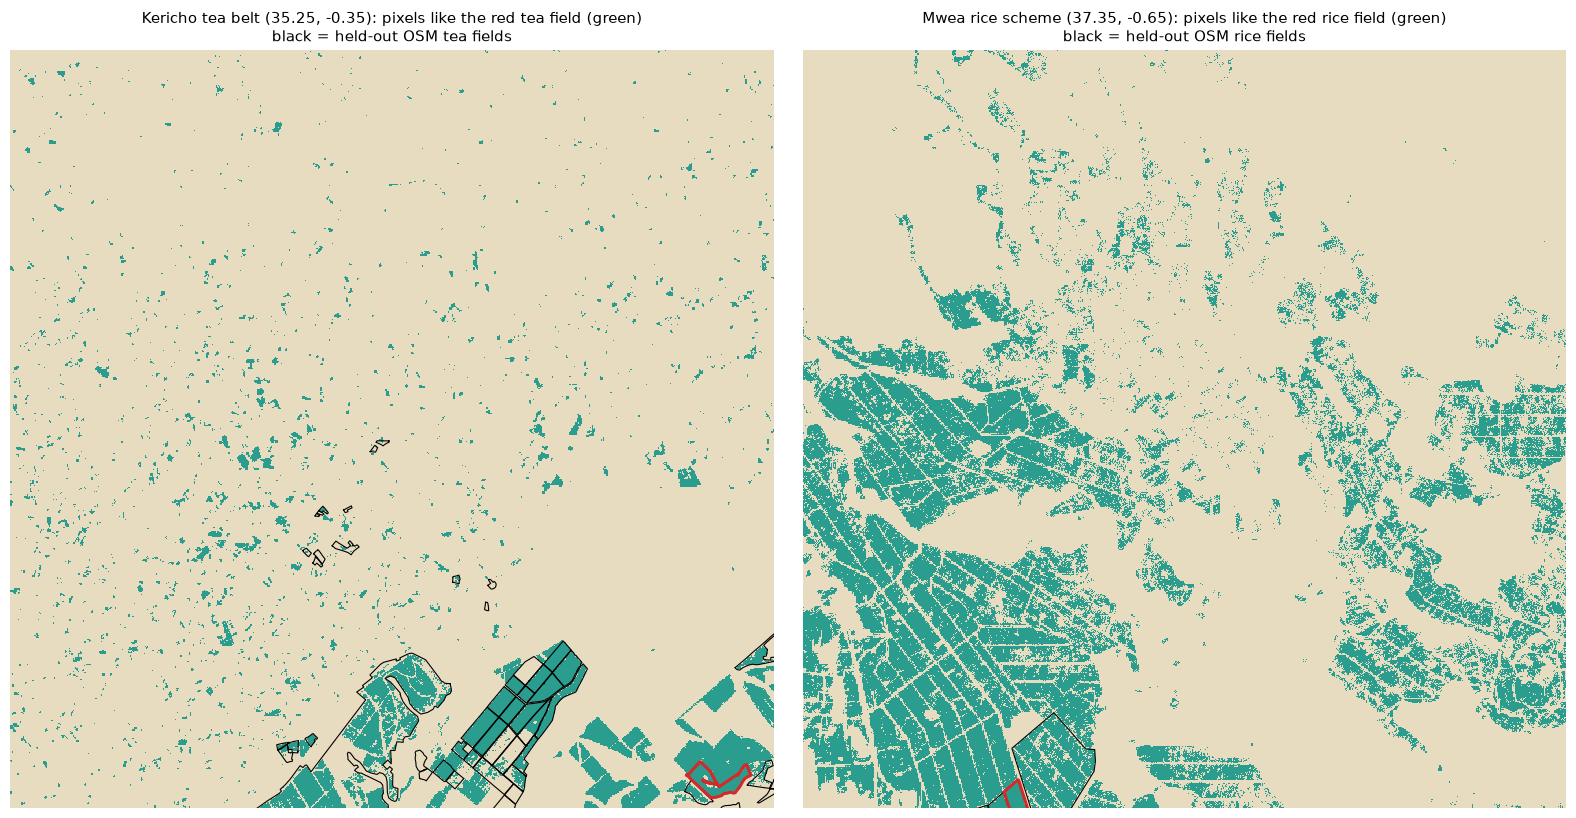

In [5]:
# ---------------------------------------------------------------------------
# THE PICTURE: Kericho, with the OSM tea fields drawn on top
# ---------------------------------------------------------------------------
def outline(ax, fields, crs, transform, **kw):
    """Draw OSM outlines in the tile's pixel coordinates."""
    inv = ~transform
    for g in fields.to_crs(crs).geometry:
        xs, ys = g.exterior.xy
        cols, rows = zip(*(inv * (x, y) for x, y in zip(xs, ys)))
        ax.plot(cols, rows, **kw)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, crop in zip(axes, ("tea", "rice")):
    qd = queries[crop]
    ax.imshow(qd["sim"] > qd["threshold"], cmap=plt.cm.colors.ListedColormap(["#e8dcc0", "#2a9d8f"]),
              interpolation="nearest")
    f = qd["fields"]
    outline(ax, f.drop(qd["qi"]), qd["crs"], qd["transform"], color="black", lw=0.8)
    outline(ax, f.loc[[qd["qi"]]], qd["crs"], qd["transform"], color="#d62828", lw=2.2)
    h, w = qd["sim"].shape
    ax.set_xlim(0, w); ax.set_ylim(h, 0)       # some OSM fields run past the tile edge
    ax.set_title(f"{TILES[qd['tile']]} {qd['tile']}: pixels like the red {crop} field (green)\n"
                 f"black = held-out OSM {crop} fields", fontsize=11)
    ax.axis("off")
plt.tight_layout(); plt.show()

On the left, the flagged pixels fill the mapped estate blocks, and also blocks
of the same shape to the east that OSM has not mapped. The scattered small
patches across the rest of the tile could be smallholder tea or false alarms;
there is no answer key for them here. On the right, the flagged pixels trace
the Mwea scheme's rectangular paddies.

## 4. The real test: every other place

Now run each fingerprint over all the tiles, with the same cut-off, and report
the share of each tile flagged. There is no answer key for most of these tiles,
but there does not need to be for the ones where the answer is obvious: there
is no tea in open Lake Victoria, the Chalbi desert, or central Nairobi.

In [6]:
# ---------------------------------------------------------------------------
# SEARCH EVERY TILE
# ---------------------------------------------------------------------------
rows = []
for tile, place in TILES.items():
    emb, _, _ = K.fetch(gt, *tile, YEAR)
    valid = K.valid_mask(emb).ravel()
    unit_px = K.unit(emb.reshape(-1, emb.shape[-1]))
    row = {"place": place, "tile": tile}
    for crop, qd in queries.items():
        row[crop] = float(np.mean((unit_px @ qd["vector"])[valid] > qd["threshold"]))
    rows.append(row)
    del emb, unit_px

found = pd.DataFrame(rows)
by_place = (found.groupby("place")[["tea", "rice"]].mean()
                 .sort_values("tea", ascending=False))
print("share of each kind of place flagged (averaged over its tiles)\n")
print(by_place.to_string(float_format=lambda v: f"{v:7.2%}"))

share of each kind of place flagged (averaged over its tiles)

                               tea    rice
place                                     
Kericho tea belt             6.35%   0.00%
Mau Forest                   0.03%   0.00%
Lamu                         0.00%   0.00%
Homa Bay farmland            0.00%   0.00%
Kitale maize                 0.00%   0.00%
Konza plains                 0.00%   0.00%
Lake Baringo area            0.00%   0.00%
Lake Turkana area            0.00%   0.00%
Lake Victoria (open water)   0.00%   0.00%
Maasai Mara savanna          0.00%   0.00%
Marsabit / Chalbi desert     0.00%   0.00%
Mombasa                      0.00%   0.00%
Mwea rice scheme             0.00%  21.33%
Nairobi                      0.00%   0.00%
Rift escarpment              0.00%   0.00%
Uasin Gishu wheat/maize      0.00%   0.00%


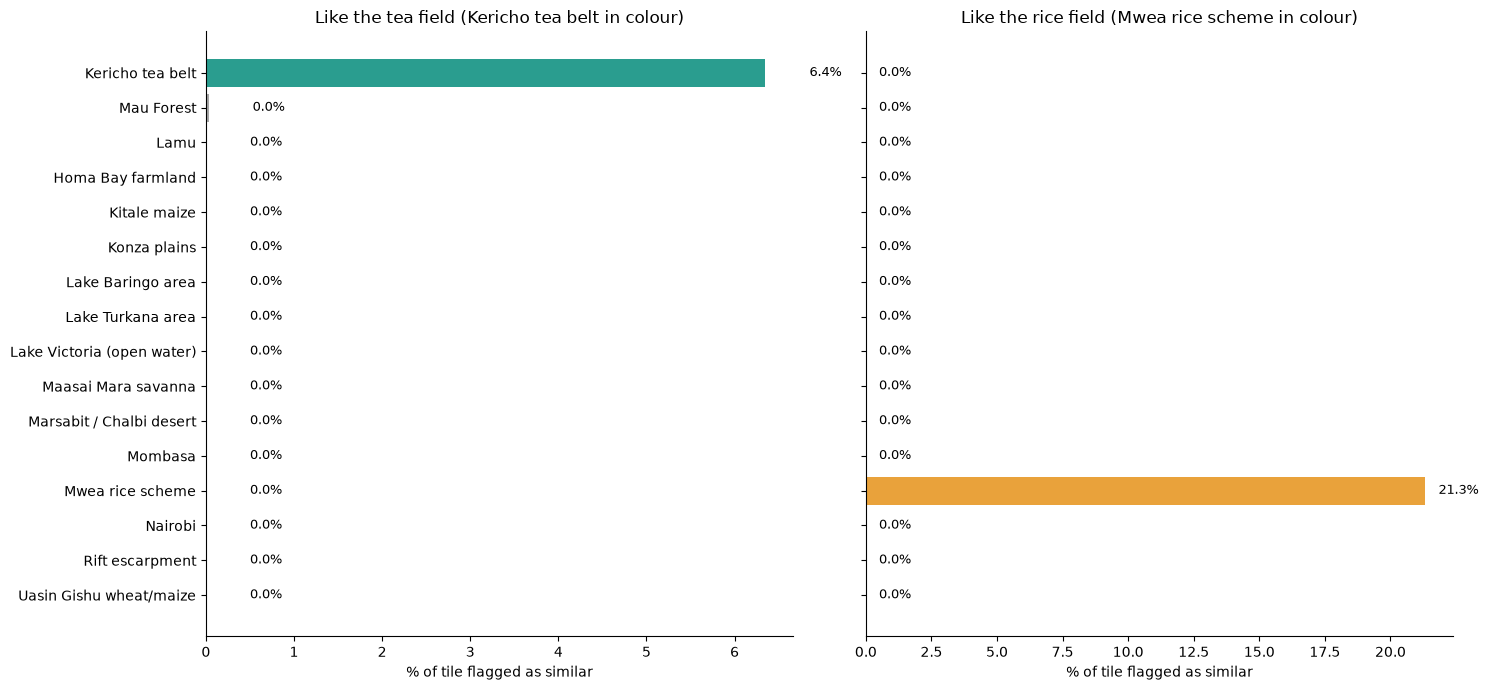

In [7]:
# ---------------------------------------------------------------------------
# THE CHART
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
order = by_place.index
for ax, crop, colour in zip(axes, ("tea", "rice"), ("#2a9d8f", "#e9a23b")):
    home = TILES[queries[crop]["tile"]]
    vals = 100 * by_place.loc[order, crop]
    bars = ax.barh(range(len(order))[::-1], vals,
                   color=[colour if p == home else "0.65" for p in order])
    for b, v in zip(bars, vals):
        ax.text(v + 0.5, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_yticks(range(len(order))[::-1]); ax.set_yticklabels(order)
    ax.set_xlabel("% of tile flagged as similar")
    ax.set_title(f"Like the {crop} field ({home} in colour)", fontsize=12)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Outside its home tile, each fingerprint finds almost nothing.** Tea is flagged
in 0.03% of the Mau Forest tile, next door to the tea belt, and in 0.00% of
every other place: savanna, desert, open water, Nairobi, and three other kinds
of farmland (Kitale maize, Uasin Gishu wheat and maize, Homa Bay). Rice is
flagged only at Mwea.

That is clean, and it is worth being clear about what it does and does not
show. It shows the cut-off is **strict enough not to raise false alarms** in
land that is plainly different. It does not show the search would find tea
*outside* Kericho, because none of the other 32 tiles is known to grow tea at
scale. That test needs another tea region in the cache (Nyeri, Kisii, Nandi
Hills).

## 5. Try it yourself

`find_like(lon, lat)` builds a query from a 50 × 50 m patch (5 × 5 pixels)
around any point, and reports, for each cached tile, the share of pixels above
the cut-off and the median similarity. The default cut-off is **0.92**, the
value §2 calibrated from real fields (0.920 for tea, 0.923 for rice). Use
`K.gmaps(lon, lat)` to check on satellite imagery what you pointed at.

There is no answer key here, so treat the output as a list of places **to
look at**, not a finding.

In [8]:
# ---------------------------------------------------------------------------
# FIND PLACES LIKE ANY POINT
# ---------------------------------------------------------------------------
def find_like(lon, lat, year=YEAR, top=8, cutoff=0.92):
    """Tiles ranked by the share of pixels similar to a 5 x 5 patch at (lon, lat)."""
    tile = K.tile_of(lon, lat)
    emb, crs, transform = K.fetch(gt, *tile, year)
    r, c = K.rowcol_of(lon, lat, emb.shape, *tile)
    patch = K.unit(emb[max(r - 2, 0):r + 3, max(c - 2, 0):c + 3].reshape(-1, emb.shape[-1]))
    q = K.unit(patch.mean(0))[0]
    out = []
    for t, place in TILES.items():
        e, _, _ = K.fetch(gt, *t, year)
        v = K.valid_mask(e).ravel()
        sim = (K.unit(e.reshape(-1, e.shape[-1])) @ q)[v]
        out.append((place, t, float(np.mean(sim > cutoff)), float(np.median(sim))))
    res = (pd.DataFrame(out, columns=["place", "tile", "share", "median"])
             .sort_values(["share", "median"], ascending=False))
    print(f"query: {K.gmaps(lon, lat)}   cut-off cosine {cutoff}\n")
    print(res.head(top).to_string(index=False, formatters={"share": "{:.2%}".format,
                                                           "median": "{:.3f}".format}))
    return res

# Example: open water in the middle of Lake Baringo.
res = find_like(36.07, 0.58)
# The two open-water tiles from K01: Lake Turkana (96.5% water) and Lake Victoria.
print("\nthe other lakes' open water:")
print(res[res.tile.isin([(35.95, 3.55), (33.95, -1.05)])].to_string(
    index=False, formatters={"share": "{:.2%}".format, "median": "{:.3f}".format}))

query: https://www.google.com/maps/@0.58000,36.07000,15z/data=!3m1!1e3   cut-off cosine 0.92

            place          tile  share median
Lake Baringo area (36.05, 0.65) 64.31%  0.982
Lake Baringo area (36.05, 0.55) 51.07%  0.928
Lake Baringo area (36.15, 0.65) 24.14%  0.248
Lake Baringo area (36.15, 0.55) 17.27%  0.236
Lake Baringo area (36.05, 0.75)  5.79%  0.227
Lake Turkana area (35.85, 3.55)  0.02%  0.271
Lake Turkana area (35.95, 3.55)  0.00%  0.724
Lake Turkana area (36.05, 3.55)  0.00%  0.688

the other lakes' open water:
                     place           tile share median
         Lake Turkana area  (35.95, 3.55) 0.00%  0.724
Lake Victoria (open water) (33.95, -1.05) 0.00%  0.445


A patch of open water in Lake Baringo finds Baringo's own water, and nothing
else: no pixel of open Lake Turkana or Lake Victoria passes the cut-off. The
medians say why. Baringo water is only **0.72** similar to open Turkana and
**0.45** to open Victoria, about as far as K01 found water is from land.

So "similar" means **this kind of place**, and each lake is its own kind:
Baringo's water is famously muddy with sediment, Turkana is an alkaline desert lake,
Victoria is a vast freshwater lake. That matters for K02 as well: its water test
still works on Baringo because the question there is only "closer to water or
to land", but a single fingerprint for "lake" would not.


## 6. What this notebook establishes

1. **One field is enough to find more of the same crop nearby.** A fingerprint
   from one 0.2 km² tea field finds 59% of 51 held-out tea fields around
   Kericho; one rice field finds 78% of the held-out rice at Mwea, and traces
   the scheme's paddies. No training, no labels beyond the one field.

2. **It does not raise false alarms in different land.** Across 33 cached tiles
   (forest, savanna, desert, lakes, coast, city, and three other kinds of
   farmland), tea is flagged only around Kericho (plus 0.03% of the neighbouring
   Mau tile), and rice only at Mwea.

3. **"Similar" is specific: each lake is its own kind of water.** Baringo's
   water is 0.72 similar to open Turkana and 0.45 to Lake Victoria, and a
   Baringo query finds neither.

**Limits, stated plainly:**

- **OSM is an incomplete answer key.** It maps some fields, not all, so "rest of
  tile flagged" is an upper bound on false alarms, not a measurement.
- **Not yet tested: finding tea in another region.** None of the other cached
  tiles grows tea at scale, so the result shows precision, not reach. The next
  test is a second tea region (Nyeri, Kisii or Nandi Hills: a few tiles, ~0.5 GB
  for one year).
- **One year only (2024).** A field replanted with a different crop would show
  up differently in other years.
- **The cut-off (cosine 0.92) was calibrated on these two crops.** It is a
  sensible default, not a law; other land types may need their own.
